# Análisis de Grupo de WhatsApp

Este notebook contiene un análisis exploratorio completo de un grupo de WhatsApp exportado.
Todos los datos personales han sido completamente anonimizados para proteger la privacidad.

## Tabla de Contenidos
1. [Importación de Bibliotecas](#1-importación-de-bibliotecas)
2. [Ingesta y Limpieza de Datos](#2-ingesta-y-limpieza-de-datos)
3. [Análisis Exploratorio de Datos](#3-análisis-exploratorio-de-datos)
4. [Análisis Adicionales](#4-análisis-adicionales)

## 1. Importación de Bibliotecas

Importamos todas las bibliotecas necesarias para el análisis.

In [24]:
# Manipulación de datos
import pandas as pd
import numpy as np
import re
import unicodedata
from datetime import datetime
from collections import Counter
import random

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Evitar warnings
import warnings
warnings.filterwarnings('ignore')

# Establecer semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

print("Bibliotecas importadas exitosamente")

Bibliotecas importadas exitosamente


## 2. Ingesta y Limpieza de Datos

### 2.1 Lectura del archivo de WhatsApp

In [25]:
# Leer el archivo de WhatsApp
archivo = 'Chat de WhatsApp con Los MascaLeales ❤️🐺.txt'

with open(archivo, 'r', encoding='utf-8') as f:
    contenido = f.read()

print(f"Archivo leído exitosamente")
print(f"Tamaño del archivo: {len(contenido):,} caracteres")

Archivo leído exitosamente
Tamaño del archivo: 725,443 caracteres


### 2.2 Parseo de mensajes con expresiones regulares

Utilizamos expresiones regulares para identificar y extraer la información de los mensajes.

In [26]:
# Patrón de expresión regular para parsear los mensajes de WhatsApp
# Formato: DD/MM/YYYY, HH:MM [a. m.|p. m.] - Usuario: Mensaje
patron_mensaje = r'(\d{1,2}/\d{1,2}/\d{4}),\s(\d{1,2}:\d{2}\s[ap]\.\sm\.)\s-\s([^:]+):\s(.+)'

# Extraer todos los mensajes usando regex
mensajes_raw = re.findall(patron_mensaje, contenido)

print(f"Mensajes extraídos: {len(mensajes_raw):,}")

Mensajes extraídos: 10,785


### 2.3 Creación del DataFrame y parseo de fechas

In [27]:
# Crear DataFrame con los mensajes
df = pd.DataFrame(mensajes_raw, columns=['fecha', 'hora', 'usuario_real', 'mensaje_original'])

# Función para parsear fecha y hora usando regex
def parsear_fecha_hora(fecha, hora):
    """Convierte la fecha y hora de WhatsApp a datetime usando regex"""
    match_hora = re.match(r'(\d{1,2}):(\d{2})\s([ap])\.\sm\.', hora)
    if match_hora:
        h, m, periodo = match_hora.groups()
        h = int(h)
        # Convertir a formato 24 horas
        if periodo == 'p' and h != 12:
            h += 12
        elif periodo == 'a' and h == 12:
            h = 0
        hora_24 = f"{h:02d}:{m}"
        return pd.to_datetime(f"{fecha} {hora_24}", format='%d/%m/%Y %H:%M')
    return pd.NaT

df['fecha_hora'] = df.apply(lambda row: parsear_fecha_hora(row['fecha'], row['hora']), axis=1)

print(f"DataFrame creado con {len(df):,} mensajes")

DataFrame creado con 10,785 mensajes


### 2.4 Anonimización completa de usuarios

Usamos nombres de personajes de Hora de Aventura y princesas de cuentos para anonimizar.
Los nombres reales NO se mostrarán en ningún resultado.

In [28]:
# Obtener usuarios únicos
usuarios_unicos = df['usuario_real'].unique()
num_usuarios = len(usuarios_unicos)

print(f"Total de usuarios únicos detectados: {num_usuarios}")

# Listas de nombres ficticios
# Personajes de Hora de Aventura y Princesas
nombres_femeninos = [
    'Princesa Chicle',
    'Marcelina la Vampira',
    'Princesa Fuego',
    'Dama Arcoiris',
    'Princesa Grumosa',
    'Princesa Slime',
    'Princesa Hot Dog',
    'Princesa Llama',
    'Princesa Fantasma',
    'Princesa Abeja',
    'Princesa Chicle Negra',
    'Huntress Wizard',  # Maga cazadora
    'Doctora Princesa',
    'Princesa del Espacio Bulto',  # Variante del nombre de Grumosa
    'Princesa Músculo',
    'Princesa Pastel',
    'Betty Grof',
    'Fionna Campbell',
    'Cake el Gato'
]

nombres_masculinos = [
    'Finn el Humano',
    'Jake el Perro',
    'Rey Helado',
    'BMO',
    'Gunter el Pingüino',
    'Mayordomo Menta',
    'Hombre Mágico',
    'Don Polvorón',
    'Rey de los Vampiros',
    'Padre de Marceline',
    'Rey Slime',
    'Rey de Fuego',
    'Earl of Lemongrab',  # Conde de Limónagrio
    'Peppermint Butler',  # Nombre original de Mayordomo Menta
    'Simon Petrikov',
    'Marshall Lee',
    'Príncipe Gumball',
    'Gary Prince'  # Versión masculina de Princesa Chicle en Fionna & Cake
]

# Mezclar los nombres
todos_los_nombres = nombres_femeninos + nombres_masculinos
random.shuffle(todos_los_nombres)

# Crear mapeo de usuarios reales a ficticios
mapeo_usuarios = {usuario_real: todos_los_nombres[i % len(todos_los_nombres)]
                  for i, usuario_real in enumerate(usuarios_unicos)}

# Asignar alias al DataFrame
df['usuario'] = df['usuario_real'].map(mapeo_usuarios)

print("Usuarios anonimizados exitosamente")
print(f"Total de nombres ficticios asignados: {len(mapeo_usuarios)}")

def remover_acentos(texto):
    """Elimina acentos para crear variantes robustas de búsqueda."""
    if not isinstance(texto, str):
        return ""
    return ''.join(c for c in unicodedata.normalize('NFKD', texto) if not unicodedata.combining(c))

stop_tokens_base = {
    'hola', 'buenos', 'buenas', 'gracias', 'favor', 'equipo',
    'grupo', 'amigos', 'familia', 'todos', 'todas', 'amigas'
}
stop_tokens = {remover_acentos(token).lower() for token in stop_tokens_base}

def generar_variaciones_nombre(nombre):
    """Genera variaciones del nombre (frases y fragmentos) sin acentos."""
    variaciones = set()
    if not isinstance(nombre, str):
        return variaciones
    nombre = nombre.strip()
    if not nombre:
        return variaciones
    variaciones.add(nombre)
    variaciones.add(remover_acentos(nombre))
    tokens = [t for t in re.split(r'[\s,.;:()\-_/]+', nombre) if len(t) > 2]
    if tokens:
        frase = ' '.join(tokens)
        variaciones.add(frase)
        variaciones.add(remover_acentos(frase))
    for size in range(1, len(tokens) + 1):
        for i in range(len(tokens) - size + 1):
            fragmento = ' '.join(tokens[i:i + size]).strip()
            if len(fragmento) < 3:
                continue
            if remover_acentos(fragmento).lower() in stop_tokens:
                continue
            variaciones.add(fragmento)
            variaciones.add(remover_acentos(fragmento))
    variaciones = {v for v in variaciones if len(v) > 2}
    return variaciones

variaciones_vistas = set()
patrones_texto = []
patrones_mencion_formal = []
patrones_mencion_simple = []

for usuario_real, alias in mapeo_usuarios.items():
    variaciones_nombre = sorted(generar_variaciones_nombre(usuario_real), key=len, reverse=True)
    for variante in variaciones_nombre:
        clave = remover_acentos(variante).lower()
        if clave in variaciones_vistas:
            continue
        variaciones_vistas.add(clave)
        patrones_texto.append((re.compile(r'(?<!\w)' + re.escape(variante) + r'(?!\w)', flags=re.IGNORECASE), alias))
        patrones_mencion_formal.append((re.compile(r'@⁨' + re.escape(variante) + r'⁩', flags=re.IGNORECASE), alias))
        patrones_mencion_simple.append((re.compile(r'@' + re.escape(variante) + r'\b', flags=re.IGNORECASE), alias))

print(f"Variaciones preparadas: {len(patrones_texto)} patrones de texto")

Total de usuarios únicos detectados: 26
Usuarios anonimizados exitosamente
Total de nombres ficticios asignados: 26
Variaciones preparadas: 155 patrones de texto


### 2.5 Anonimización de mensajes

Reemplazamos los nombres reales que aparecen en los mensajes por sus versiones anonimizadas.

In [30]:
def anonimizar_mensaje(mensaje):
    """Reemplaza nombres y menciones usando las variantes generadas."""
    if not isinstance(mensaje, str):
        return mensaje
    resultado = mensaje

    # Menciones con formato especial de WhatsApp
    for patron, alias in patrones_mencion_formal:
        resultado = patron.sub(lambda _: f'@⁨{alias}⁩', resultado)

    # Menciones escritas manualmente (ej. @Juan)
    for patron, alias in patrones_mencion_simple:
        resultado = patron.sub(lambda _: f'@{alias}', resultado)

    # Nombres aislados dentro del texto
    for patron, alias in patrones_texto:
        resultado = patron.sub(alias, resultado)

    # Ocultar números telefónicos que aparezcan en conversaciones
    resultado = re.sub(r'\+?\d{1,3}\s?\d{2,4}\s?\d{3}\s?\d{4}', '[contacto anon]', resultado)
    return resultado

# Aplicar anonimización a los mensajes
df['mensaje'] = df['mensaje_original'].apply(anonimizar_mensaje)

print("Mensajes anonimizados exitosamente")
print("Todos los nombres reales han sido reemplazados en el contenido de los mensajes")

Mensajes anonimizados exitosamente
Todos los nombres reales han sido reemplazados en el contenido de los mensajes


### 2.6 Clasificación de tipos de mensajes

Utilizamos expresiones regulares para identificar diferentes tipos de contenido.

In [31]:
def clasificar_tipo_mensaje(mensaje):
    """Clasifica el tipo de mensaje usando expresiones regulares"""
    
    # Patrón para multimedia
    if re.search(r'<Multimedia omitido>', mensaje):
        return 'multimedia'
    
    # Patrón para stickers
    if re.search(r'sticker', mensaje, re.IGNORECASE):
        return 'sticker'
    
    # Patrón para encuestas
    if re.search(r'ENCUESTA:|OPCIÓN:', mensaje):
        return 'encuesta'
    
    # Patrón para mensajes del sistema
    if re.search(r'‎.*?(creó el grupo|añadió|cambió|quitó|salió|se unió)', mensaje):
        return 'sistema'
    
    # Patrón para URLs
    if re.search(r'https?://[^\s]+', mensaje):
        return 'enlace'
    
    # Patrón para mensajes eliminados
    if re.search(r'eliminaste este mensaje|mensaje eliminado', mensaje, re.IGNORECASE):
        return 'eliminado'
    
    # Patrón para mensajes de voz
    if re.search(r'audio|voz', mensaje, re.IGNORECASE):
        return 'audio'
    
    return 'texto'

# Aplicar la clasificación
df['tipo_mensaje'] = df['mensaje'].apply(clasificar_tipo_mensaje)

print("Mensajes clasificados por tipo")
print("\nDistribución:")
print(df['tipo_mensaje'].value_counts())

Mensajes clasificados por tipo

Distribución:
tipo_mensaje
texto         7744
multimedia    2882
enlace         100
sticker         33
encuesta        20
audio            6
Name: count, dtype: int64


### 2.7 Extracción de características adicionales

In [32]:
def contar_palabras(mensaje):
    """Cuenta palabras usando regex"""
    if re.search(r'<Multimedia omitido>|‎', mensaje):
        return 0
    palabras = re.findall(r'\b\w+\b', mensaje)
    return len(palabras)

def contar_emojis(mensaje):
    """Cuenta emojis usando regex Unicode"""
    patron_emoji = re.compile("["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    return len(patron_emoji.findall(mensaje))

def extraer_menciones(mensaje):
    """Extrae menciones usando regex"""
    menciones = re.findall(r'@⁨([^⁩]+)⁩', mensaje)
    return len(menciones)

# Aplicar las funciones
df['num_palabras'] = df['mensaje'].apply(contar_palabras)
df['num_emojis'] = df['mensaje'].apply(contar_emojis)
df['num_menciones'] = df['mensaje'].apply(extraer_menciones)

# Extraer información temporal
df['dia_semana'] = df['fecha_hora'].dt.day_name()
df['hora_dia'] = df['fecha_hora'].dt.hour
df['mes'] = df['fecha_hora'].dt.month
df['dia'] = df['fecha_hora'].dt.day
df['fecha_simple'] = df['fecha_hora'].dt.date

print("Características extraídas exitosamente")
print(f"\nColumnas del DataFrame: {df.shape[1]}")
print(f"Total de filas: {df.shape[0]:,}")

Características extraídas exitosamente

Columnas del DataFrame: 16
Total de filas: 10,785


### 2.8 Limpieza final y preparación

Eliminamos las columnas con datos sensibles para que no aparezcan en los resultados.

In [33]:
# Eliminar columnas con información sensible
df_limpio = df.drop(columns=['usuario_real', 'mensaje_original'])

# Filtrar mensajes de sistema para análisis
df_analisis = df_limpio[df_limpio['tipo_mensaje'] != 'sistema'].copy()

print("Datos listos para análisis")
print(f"\nColumnas disponibles para análisis:")
for col in df_analisis.columns:
    print(f"  - {col}")

print(f"\nMensajes totales (sin sistema): {len(df_analisis):,}")

Datos listos para análisis

Columnas disponibles para análisis:
  - fecha
  - hora
  - fecha_hora
  - usuario
  - mensaje
  - tipo_mensaje
  - num_palabras
  - num_emojis
  - num_menciones
  - dia_semana
  - hora_dia
  - mes
  - dia
  - fecha_simple

Mensajes totales (sin sistema): 10,785


## 3. Análisis Exploratorio de Datos

### 3.1 Estadísticas Descriptivas

In [34]:
# Estadísticas generales
total_mensajes = len(df_analisis)
total_usuarios = df_analisis['usuario'].nunique()
promedio_mensajes = total_mensajes / total_usuarios
total_palabras = df_analisis['num_palabras'].sum()
promedio_palabras = df_analisis['num_palabras'].mean()

# Fecha de inicio y fin
fecha_inicio = df_analisis['fecha_hora'].min()
fecha_fin = df_analisis['fecha_hora'].max()
dias_activos = (fecha_fin - fecha_inicio).days

print("="*60)
print("ESTADÍSTICAS DESCRIPTIVAS DEL GRUPO")
print("="*60)
print(f"\nPeríodo de análisis:")
print(f"   Inicio: {fecha_inicio.strftime('%d/%m/%Y')}")
print(f"   Fin: {fecha_fin.strftime('%d/%m/%Y')}")
print(f"   Duración: {dias_activos} días")

print(f"\nMensajes:")
print(f"   Total de mensajes: {total_mensajes:,}")
print(f"   Mensajes por día: {total_mensajes/dias_activos:.2f}")

print(f"\nUsuarios:")
print(f"   Total de usuarios: {total_usuarios}")
print(f"   Promedio de mensajes por usuario: {promedio_mensajes:.2f}")

print(f"\nPalabras:")
print(f"   Total de palabras: {total_palabras:,}")
print(f"   Promedio de palabras por mensaje: {promedio_palabras:.2f}")

print(f"\nDistribución por tipo de mensaje:")
for tipo, count in df_analisis['tipo_mensaje'].value_counts().items():
    porcentaje = (count / total_mensajes) * 100
    print(f"   {tipo.capitalize()}: {count:,} ({porcentaje:.1f}%)")

print("\n" + "="*60)

ESTADÍSTICAS DESCRIPTIVAS DEL GRUPO

Período de análisis:
   Inicio: 27/03/2024
   Fin: 06/11/2025
   Duración: 589 días

Mensajes:
   Total de mensajes: 10,785
   Mensajes por día: 18.31

Usuarios:
   Total de usuarios: 26
   Promedio de mensajes por usuario: 414.81

Palabras:
   Total de palabras: 39,819
   Promedio de palabras por mensaje: 3.69

Distribución por tipo de mensaje:
   Texto: 7,744 (71.8%)
   Multimedia: 2,882 (26.7%)
   Enlace: 100 (0.9%)
   Sticker: 33 (0.3%)
   Encuesta: 20 (0.2%)
   Audio: 6 (0.1%)



### 3.2 Nube de Palabras

¿Cómo se habla en este grupo?

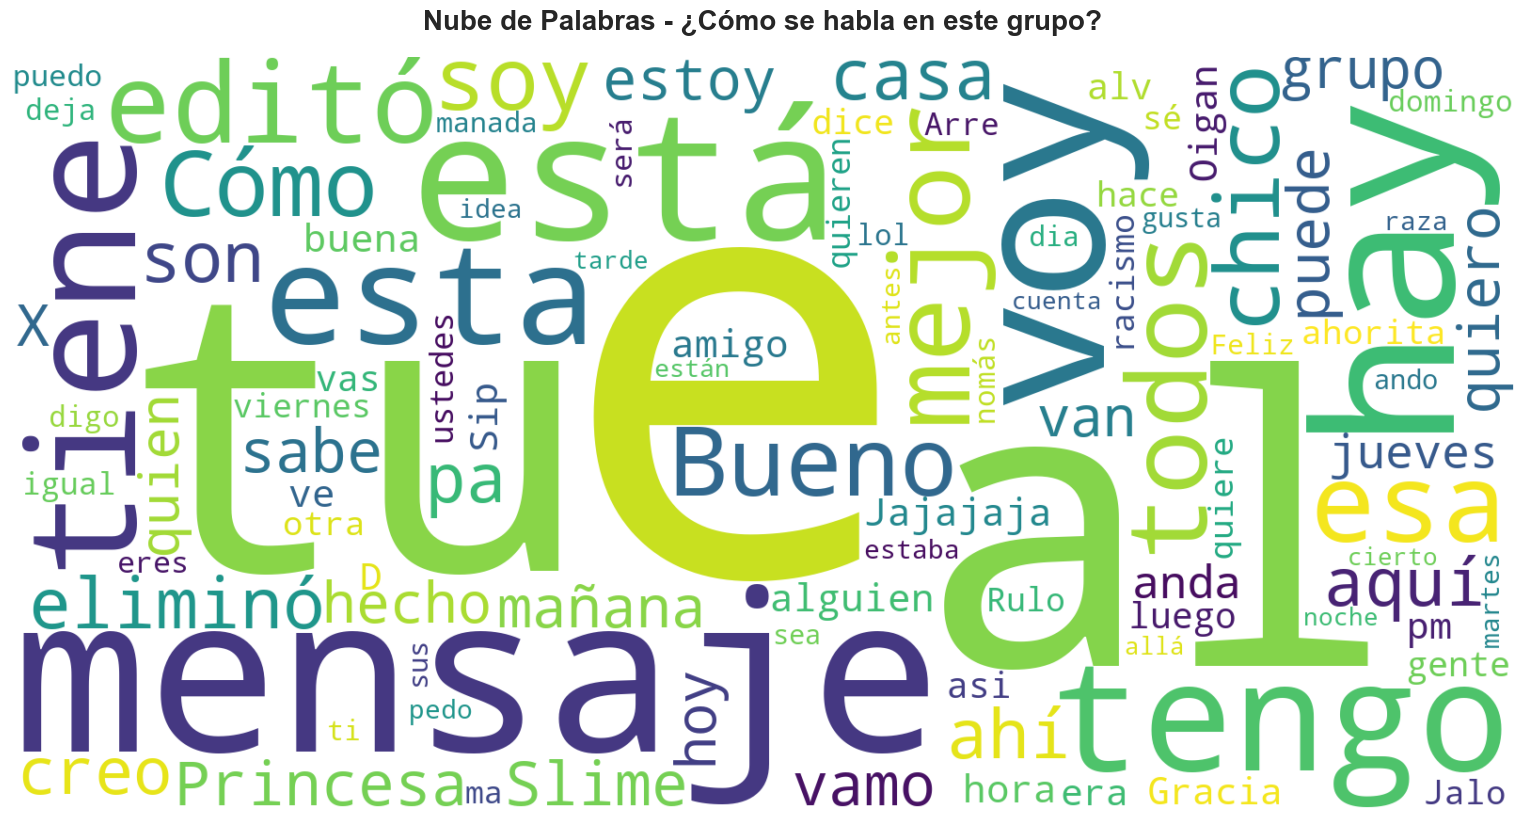


Nube de palabras generada con 7,744 mensajes de texto
Nombres excluidos adicionales del .env: 6


In [35]:
# Filtrar solo mensajes de texto
mensajes_texto = df_analisis[df_analisis['tipo_mensaje'] == 'texto']['mensaje'].tolist()

# Combinar todos los mensajes
texto_completo = ' '.join(mensajes_texto)

# Limpiar texto con regex
texto_limpio = re.sub(r'https?://\S+', '', texto_completo)
texto_limpio = re.sub(r'@⁨[^⁩]+⁩', '', texto_limpio)
texto_limpio = re.sub(r'@\w+', '', texto_limpio)  # Eliminar menciones manuales también
texto_limpio = re.sub(r'\d+', '', texto_limpio)

# Cargar nombres a excluir del archivo .env
nombres_a_excluir = set()
try:
    with open('.env', 'r', encoding='utf-8') as f:
        for linea in f:
            linea = linea.strip()
            # Ignorar líneas vacías y comentarios
            if linea and not linea.startswith('#'):
                # Agregar el nombre y su versión sin acentos
                nombres_a_excluir.add(linea.lower())
                nombres_a_excluir.add(remover_acentos(linea).lower())
except FileNotFoundError:
    print("Advertencia: No se encontró archivo .env, continuando sin nombres adicionales a excluir")

# Stopwords en español
stopwords_es = set([
    'el', 'la', 'de', 'que', 'y', 'a', 'en', 'un', 'ser', 'se', 'no', 'haber',
    'por', 'con', 'su', 'para', 'como', 'estar', 'tener', 'le', 'lo', 'todo',
    'pero', 'más', 'hacer', 'o', 'poder', 'decir', 'este', 'ir', 'otro', 'ese',
    'si', 'me', 'ya', 'ver', 'porque', 'dar', 'cuando', 'él', 'muy', 'sin',
    'vez', 'mucho', 'saber', 'qué', 'sobre', 'mi', 'alguno', 'mismo', 'yo',
    'también', 'hasta', 'año', 'dos', 'querer', 'entre', 'así', 'primero',
    'desde', 'grande', 'eso', 'ni', 'nos', 'llegar', 'pasar', 'tiempo', 'ella',
    'sí', 'día', 'uno', 'bien', 'poco', 'deber', 'entonces', 'poner', 'cosa',
    'tanto', 'hombre', 'parecer', 'nuestro', 'tan', 'donde', 'ahora', 'parte',
    'después', 'vida', 'quedar', 'siempre', 'creer', 'hablar', 'llevar', 'dejar',
    'nada', 'cada', 'seguir', 'menos', 'nuevo', 'encontrar', 'algo', 'solo',
    'decir', 'tú', 'va', 'pues', 'te', 'les', 'fue', 'del', 'los', 'las', 'una',
    'ah', 'oh', 'jaja', 'jajaja', 'jeje', 'jjj', 'xd', 'omg', 'ok', 'we', 'wey'
])

# Combinar stopwords con nombres a excluir
todas_stopwords = stopwords_es | nombres_a_excluir

# Crear wordcloud
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=todas_stopwords,
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(texto_limpio)

# Visualizar
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras - ¿Cómo se habla en este grupo?', fontsize=20, pad=20, weight='bold')
plt.tight_layout(pad=0)
plt.show()

print(f"\nNube de palabras generada con {len(mensajes_texto):,} mensajes de texto")
print(f"Nombres excluidos adicionales del .env: {len(nombres_a_excluir)}")

### 3.3 Usuarios Más Activos

¿Quiénes son los que más escriben?

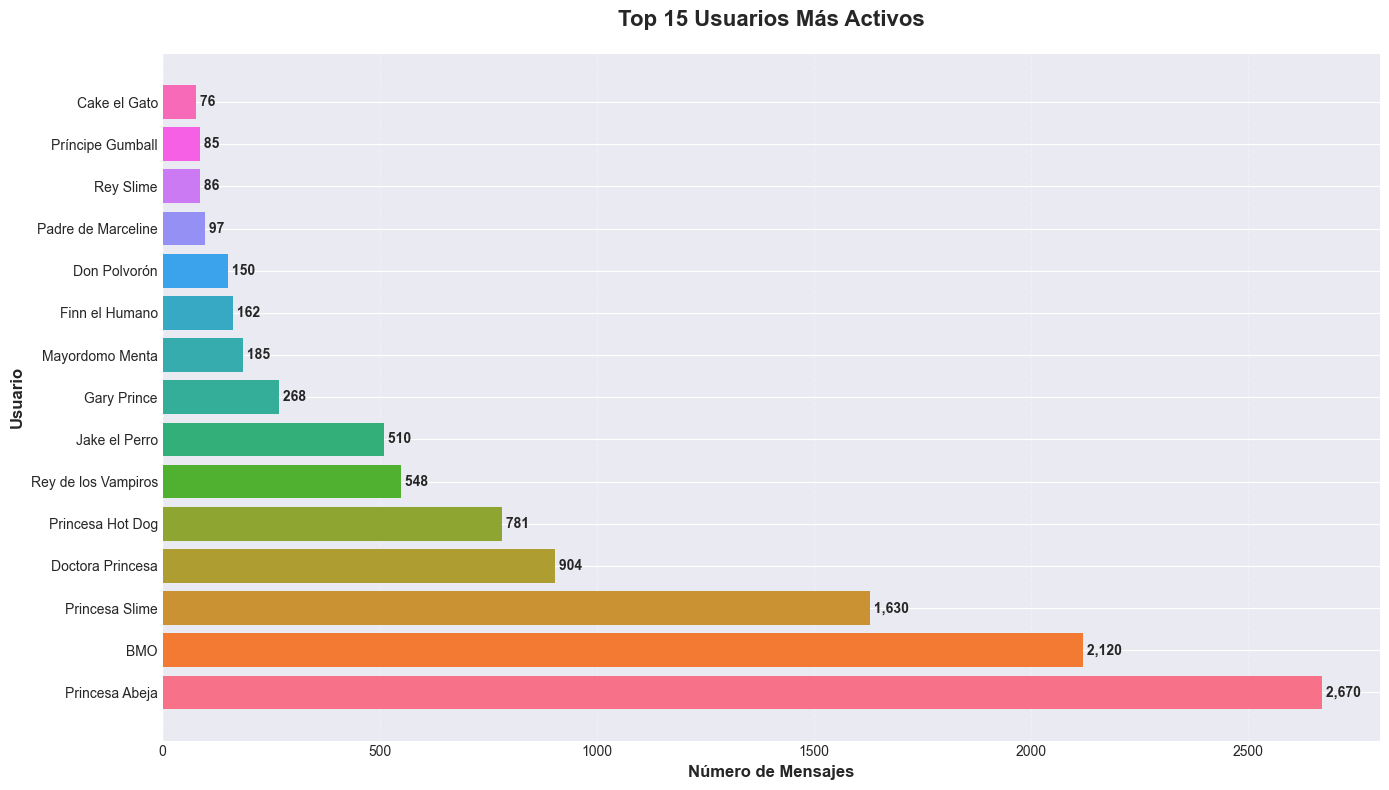


Top 5 usuarios más activos:
1. Princesa Abeja: 2,670 mensajes (24.8%)
2. BMO: 2,120 mensajes (19.7%)
3. Princesa Slime: 1,630 mensajes (15.1%)
4. Doctora Princesa: 904 mensajes (8.4%)
5. Princesa Hot Dog: 781 mensajes (7.2%)


In [36]:
# Contar mensajes por usuario
mensajes_por_usuario = df_analisis['usuario'].value_counts().head(15)

# Crear gráfica
plt.figure(figsize=(14, 8))
colores = sns.color_palette('husl', len(mensajes_por_usuario))
bars = plt.barh(range(len(mensajes_por_usuario)), mensajes_por_usuario.values, color=colores)

plt.yticks(range(len(mensajes_por_usuario)), mensajes_por_usuario.index)
plt.xlabel('Número de Mensajes', fontsize=12, weight='bold')
plt.ylabel('Usuario', fontsize=12, weight='bold')
plt.title('Top 15 Usuarios Más Activos', fontsize=16, pad=20, weight='bold')

# Añadir valores
for i, (bar, valor) in enumerate(zip(bars, mensajes_por_usuario.values)):
    plt.text(valor, i, f' {valor:,}', va='center', fontsize=10, weight='bold')

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nTop 5 usuarios más activos:")
for i, (usuario, count) in enumerate(mensajes_por_usuario.head(5).items(), 1):
    porcentaje = (count / total_mensajes) * 100
    print(f"{i}. {usuario}: {count:,} mensajes ({porcentaje:.1f}%)")

### 3.4 Distribución por Hora del Día

¿A qué horas se envían más mensajes?

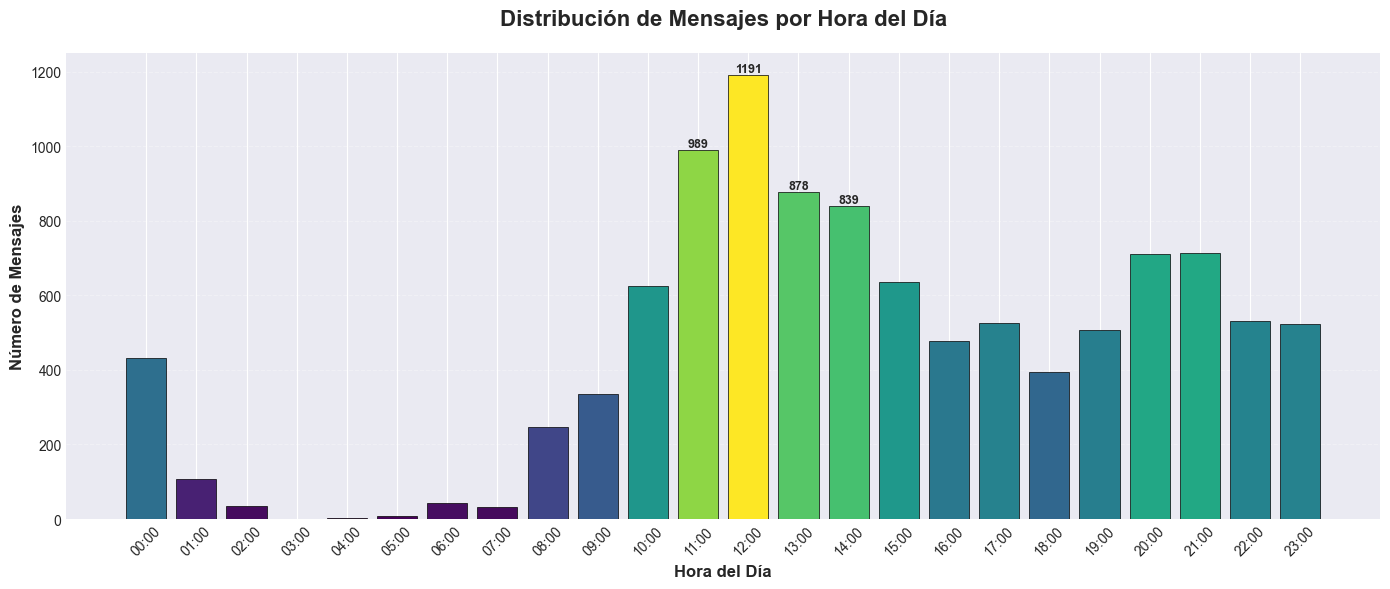


Top 5 horas más activas:
   12:00 - 1,191 mensajes
   11:00 - 989 mensajes
   13:00 - 878 mensajes
   14:00 - 839 mensajes
   21:00 - 714 mensajes


In [37]:
# Contar mensajes por hora
mensajes_por_hora = df_analisis.groupby('hora_dia').size()

# Crear gráfica
plt.figure(figsize=(14, 6))
colores = plt.cm.viridis(mensajes_por_hora.values / mensajes_por_hora.max())
bars = plt.bar(mensajes_por_hora.index, mensajes_por_hora.values, color=colores, edgecolor='black', linewidth=0.5)

plt.xlabel('Hora del Día', fontsize=12, weight='bold')
plt.ylabel('Número de Mensajes', fontsize=12, weight='bold')
plt.title('Distribución de Mensajes por Hora del Día', fontsize=16, pad=20, weight='bold')
plt.xticks(range(0, 24), [f'{h:02d}:00' for h in range(0, 24)], rotation=45)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Añadir valores en barras altas
max_height = mensajes_por_hora.max()
for bar in bars:
    height = bar.get_height()
    if height > max_height * 0.7:
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

# Top 5 horas
top_horas = mensajes_por_hora.nlargest(5)
print(f"\nTop 5 horas más activas:")
for hora, count in top_horas.items():
    print(f"   {hora:02d}:00 - {count:,} mensajes")

### 3.5 Actividad por Día de la Semana

¿Qué días son los más activos?

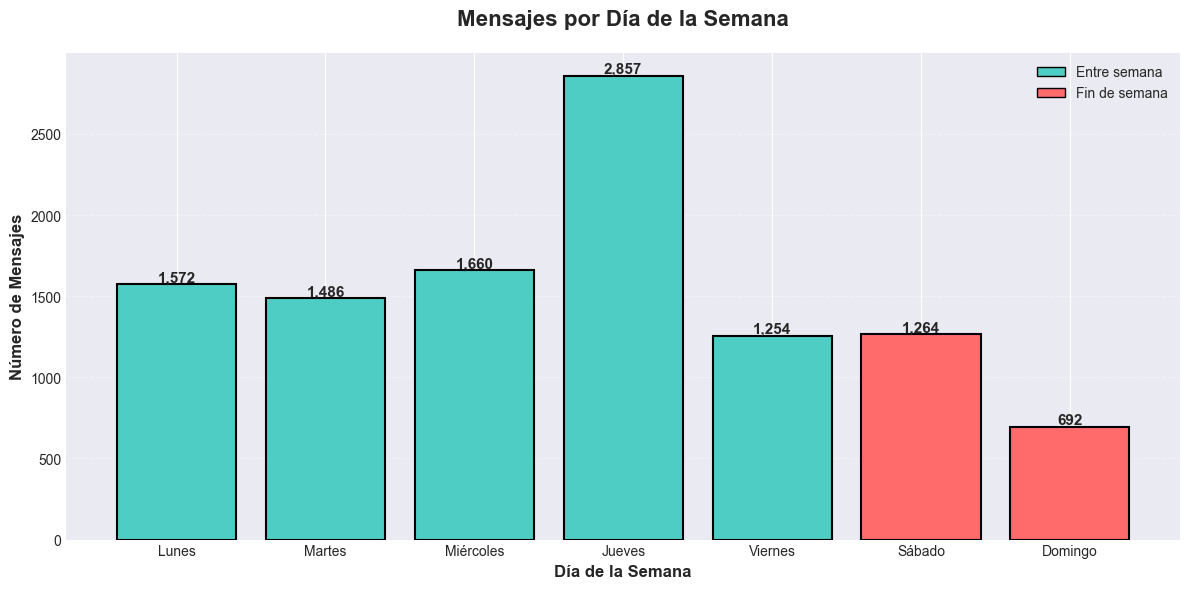


Estadísticas por período:
   Promedio entre semana: 1766 mensajes/día
   Promedio fin de semana: 978 mensajes/día
   Diferencia: 788 mensajes/día


In [38]:
# Traducir días al español
dias_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

df_analisis['dia_semana_es'] = df_analisis['dia_semana'].map(dias_es)

# Ordenar días
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
mensajes_por_dia = df_analisis['dia_semana_es'].value_counts().reindex(orden_dias)

# Crear gráfica
plt.figure(figsize=(12, 6))
colores_dias = ['#FF6B6B' if dia in ['Sábado', 'Domingo'] else '#4ECDC4' for dia in orden_dias]
bars = plt.bar(orden_dias, mensajes_por_dia.values, color=colores_dias, edgecolor='black', linewidth=1.5)

plt.xlabel('Día de la Semana', fontsize=12, weight='bold')
plt.ylabel('Número de Mensajes', fontsize=12, weight='bold')
plt.title('Mensajes por Día de la Semana', fontsize=16, pad=20, weight='bold')

# Añadir valores
for bar, valor in zip(bars, mensajes_por_dia.values):
    plt.text(bar.get_x() + bar.get_width()/2., valor,
            f'{int(valor):,}',
            ha='center', va='bottom', fontsize=11, weight='bold')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Entre semana'),
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Fin de semana')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Estadísticas
promedio_semana = mensajes_por_dia[:5].mean()
promedio_fin = mensajes_por_dia[5:].mean()

print(f"\nEstadísticas por período:")
print(f"   Promedio entre semana: {promedio_semana:.0f} mensajes/día")
print(f"   Promedio fin de semana: {promedio_fin:.0f} mensajes/día")
print(f"   Diferencia: {abs(promedio_semana - promedio_fin):.0f} mensajes/día")

### 3.6 Análisis Texto vs Multimedia

¿Quién genera conversación y quién la estimula?

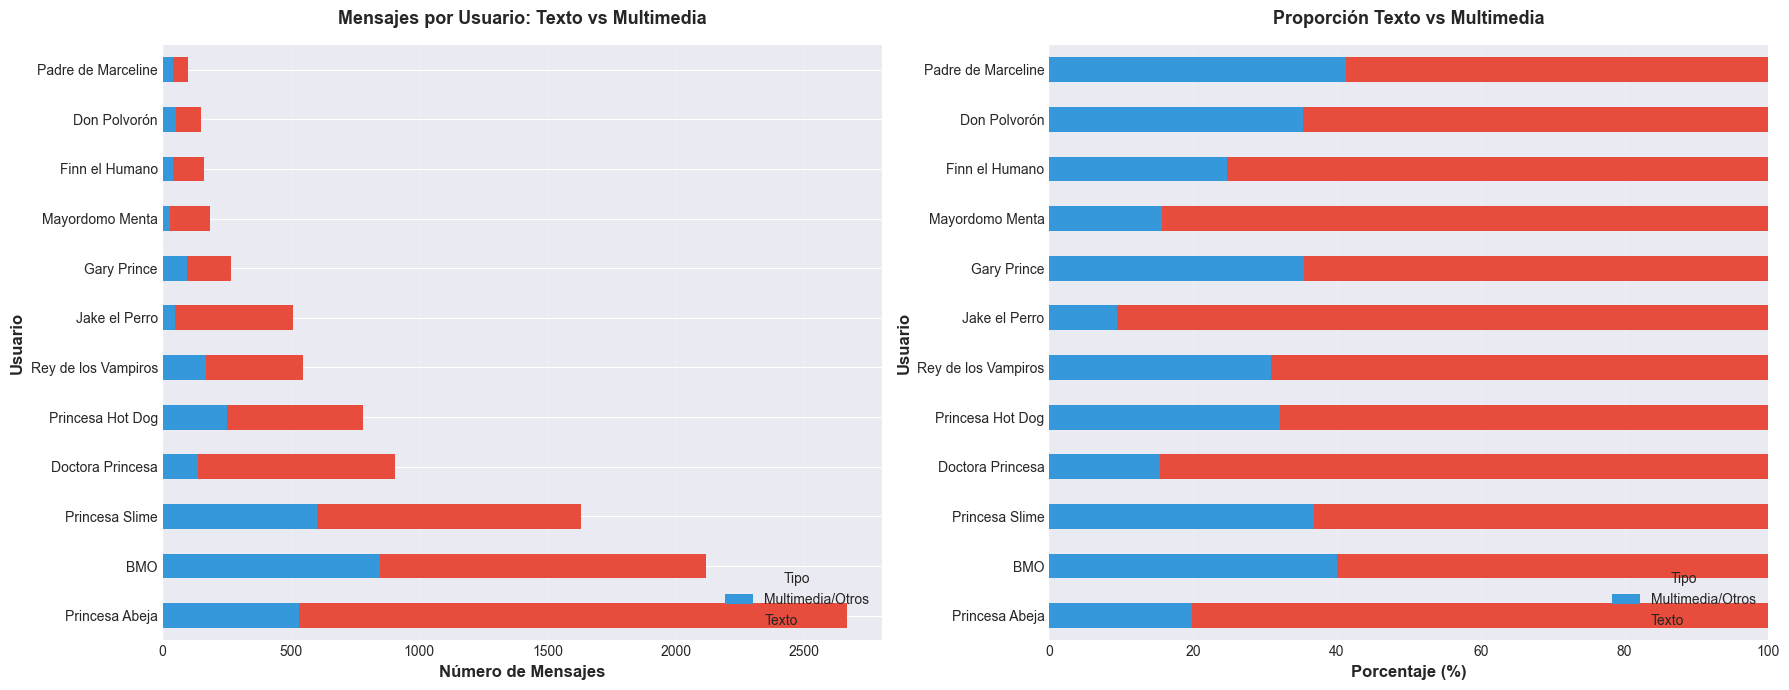


Análisis de perfiles:


Princesa Abeja:
  Perfil: GENERADOR de conversación
  Texto: 2139 (80.1%) | Multimedia: 531 (19.9%)

BMO:
  Perfil: EQUILIBRADO
  Texto: 1273 (60.0%) | Multimedia: 847 (40.0%)

Princesa Slime:
  Perfil: EQUILIBRADO
  Texto: 1030 (63.2%) | Multimedia: 600 (36.8%)

Doctora Princesa:
  Perfil: GENERADOR de conversación
  Texto: 765 (84.6%) | Multimedia: 139 (15.4%)

Princesa Hot Dog:
  Perfil: EQUILIBRADO
  Texto: 531 (68.0%) | Multimedia: 250 (32.0%)

Rey de los Vampiros:
  Perfil: EQUILIBRADO
  Texto: 379 (69.2%) | Multimedia: 169 (30.8%)

Jake el Perro:
  Perfil: GENERADOR de conversación
  Texto: 462 (90.6%) | Multimedia: 48 (9.4%)

Gary Prince:
  Perfil: EQUILIBRADO
  Texto: 173 (64.6%) | Multimedia: 95 (35.4%)



In [39]:
# Categorizar mensajes
df_analisis['categoria'] = df_analisis['tipo_mensaje'].apply(
    lambda x: 'Texto' if x == 'texto' else 'Multimedia/Otros'
)

# Crear tabla cruzada
tabla_usuario_tipo = pd.crosstab(df_analisis['usuario'], df_analisis['categoria'])

# Top 12 usuarios
top_usuarios = df_analisis['usuario'].value_counts().head(12).index
tabla_filtrada = tabla_usuario_tipo.loc[top_usuarios]

# Calcular porcentajes
tabla_porcentajes = tabla_filtrada.div(tabla_filtrada.sum(axis=1), axis=0) * 100

# Crear gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfica 1: Valores absolutos
tabla_filtrada.plot(kind='barh', stacked=True, ax=ax1, color=['#3498db', '#e74c3c'])
ax1.set_xlabel('Número de Mensajes', fontsize=12, weight='bold')
ax1.set_ylabel('Usuario', fontsize=12, weight='bold')
ax1.set_title('Mensajes por Usuario: Texto vs Multimedia', fontsize=13, pad=15, weight='bold')
ax1.legend(title='Tipo', loc='lower right')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Gráfica 2: Porcentajes
tabla_porcentajes.plot(kind='barh', stacked=True, ax=ax2, color=['#3498db', '#e74c3c'])
ax2.set_xlabel('Porcentaje (%)', fontsize=12, weight='bold')
ax2.set_ylabel('Usuario', fontsize=12, weight='bold')
ax2.set_title('Proporción Texto vs Multimedia', fontsize=13, pad=15, weight='bold')
ax2.legend(title='Tipo', loc='lower right')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Análisis por perfil
print("\nAnálisis de perfiles:\n")
print("="*70)

for usuario in top_usuarios[:8]:
    texto = tabla_filtrada.loc[usuario, 'Texto']
    multimedia = tabla_filtrada.loc[usuario, 'Multimedia/Otros']
    total = texto + multimedia
    pct_texto = (texto / total) * 100
    pct_multimedia = (multimedia / total) * 100
    
    if pct_texto > 70:
        perfil = "GENERADOR de conversación"
    elif pct_multimedia > 50:
        perfil = "ESTIMULADOR con multimedia"
    else:
        perfil = "EQUILIBRADO"
    
    print(f"\n{usuario}:")
    print(f"  Perfil: {perfil}")
    print(f"  Texto: {texto} ({pct_texto:.1f}%) | Multimedia: {multimedia} ({pct_multimedia:.1f}%)")

print("\n" + "="*70)

## 4. Análisis Adicionales

### 4.1 Evolución Temporal del Grupo

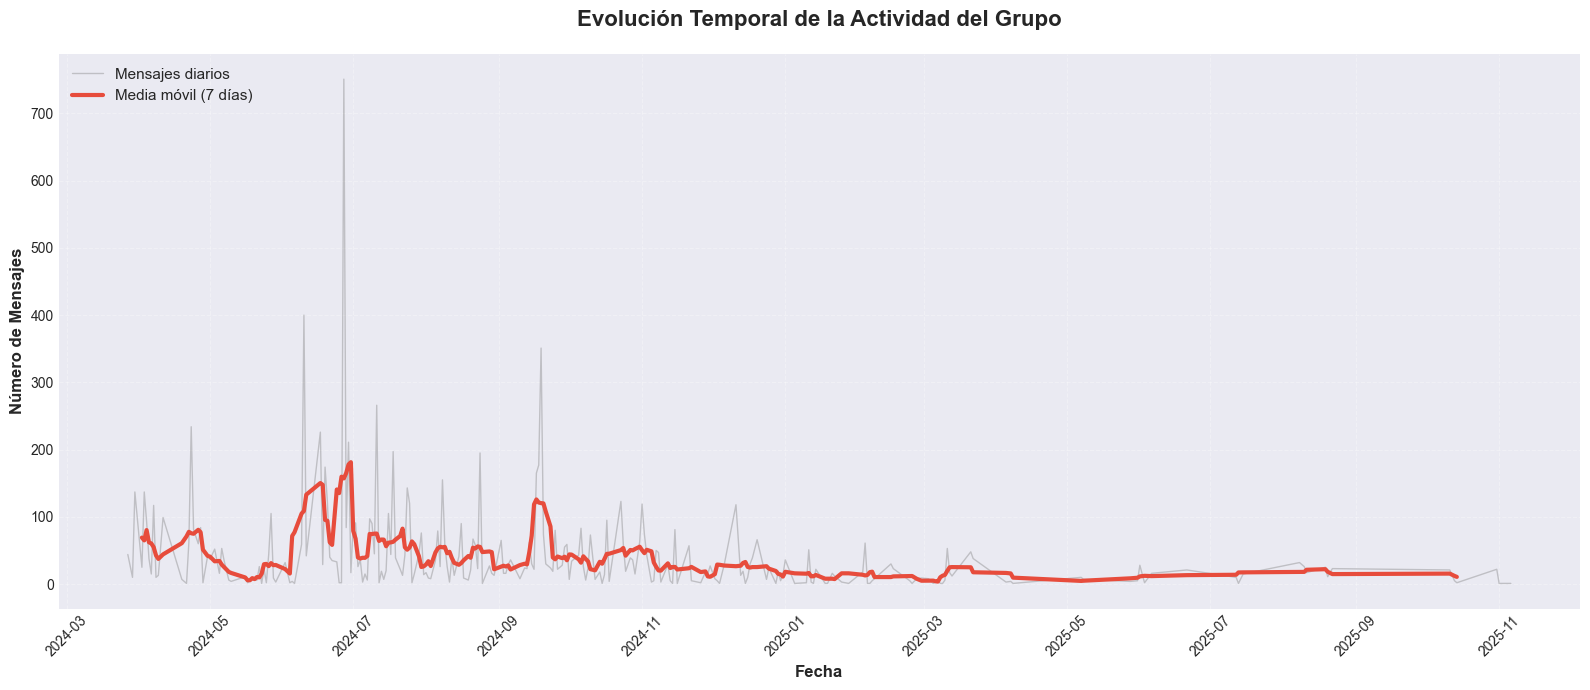


Top 5 días con más actividad:
   2024-06-27: 751 mensajes
   2024-06-10: 400 mensajes
   2024-09-19: 351 mensajes
   2024-07-11: 266 mensajes
   2024-04-23: 234 mensajes

Estadísticas de actividad diaria:
   Promedio: 41.3 mensajes/día
   Mediana: 21 mensajes/día
   Máximo: 751 mensajes
   Mínimo: 1 mensajes


In [40]:
# Agrupar por fecha
mensajes_por_fecha = df_analisis.groupby('fecha_simple').size()

# Media móvil de 7 días
media_movil = mensajes_por_fecha.rolling(window=7, center=True).mean()

# Crear gráfica
plt.figure(figsize=(16, 7))

plt.plot(mensajes_por_fecha.index, mensajes_por_fecha.values, 
         alpha=0.4, linewidth=1, color='gray', label='Mensajes diarios')

plt.plot(media_movil.index, media_movil.values, 
         linewidth=3, color='#e74c3c', label='Media móvil (7 días)')

plt.xlabel('Fecha', fontsize=12, weight='bold')
plt.ylabel('Número de Mensajes', fontsize=12, weight='bold')
plt.title('Evolución Temporal de la Actividad del Grupo', fontsize=16, pad=20, weight='bold')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top días
top_dias = mensajes_por_fecha.nlargest(5)
print("\nTop 5 días con más actividad:")
for fecha, count in top_dias.items():
    print(f"   {fecha}: {count:,} mensajes")

print(f"\nEstadísticas de actividad diaria:")
print(f"   Promedio: {mensajes_por_fecha.mean():.1f} mensajes/día")
print(f"   Mediana: {mensajes_por_fecha.median():.0f} mensajes/día")
print(f"   Máximo: {mensajes_por_fecha.max()} mensajes")
print(f"   Mínimo: {mensajes_por_fecha.min()} mensajes")

### 4.2 Análisis de Menciones

¿Quiénes son el centro de atención?

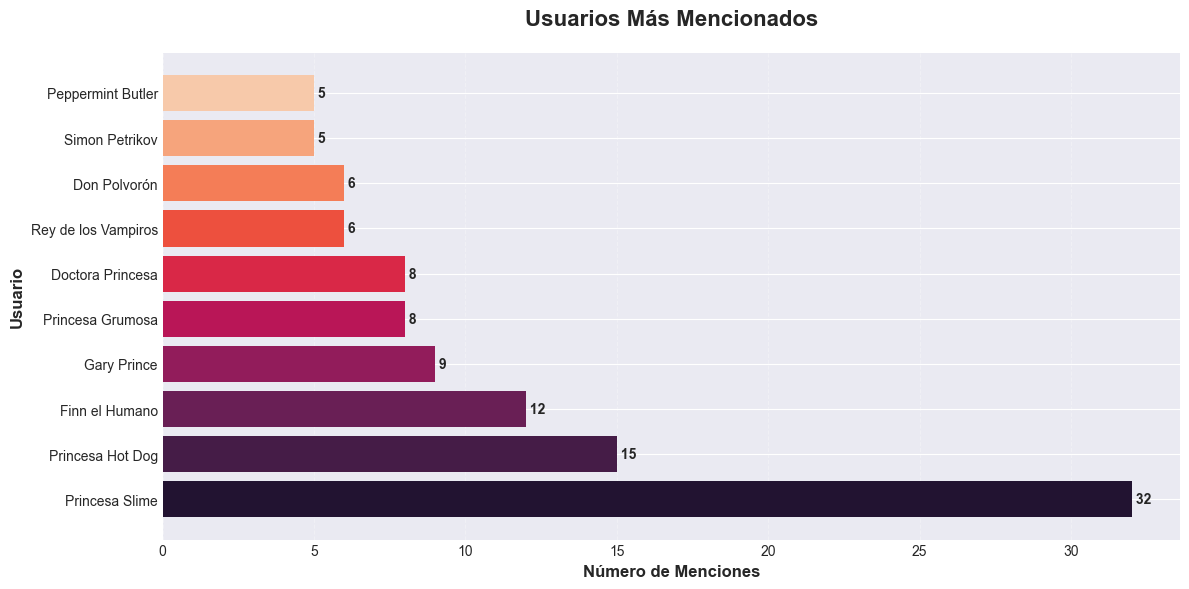


Total de menciones (anonimizadas): 113
Menciones no identificadas o parciales: 105

Top 5 usuarios más mencionados:
1. Princesa Slime: 32 menciones
2. Princesa Hot Dog: 15 menciones
3. Finn el Humano: 12 menciones
4. Gary Prince: 9 menciones
5. Princesa Grumosa: 8 menciones

Mensajes con menciones: 179 (1.7%)


In [41]:
def extraer_todas_menciones(mensaje):
    """Extrae lista de menciones anonimizadas"""
    # Buscar menciones en formato @⁨nombre⁩ (WhatsApp formal)
    menciones_formal = re.findall(r'@⁨([^⁩]+)⁩', mensaje)
    # Buscar menciones en formato @nombre (manual)
    menciones_manual = re.findall(r'@(\w+(?:\s+\w+)*)', mensaje)
    return menciones_formal + menciones_manual

df_analisis['menciones_lista'] = df_analisis['mensaje'].apply(extraer_todas_menciones)

# Contar menciones (solo de alias anonimizados)
todas_menciones = [mencion for lista in df_analisis['menciones_lista'] for mencion in lista]

# Filtrar: mantener solo menciones que sean aliases válidos (están en nuestro mapeo de alias)
aliases_validos = set(mapeo_usuarios.values())
todas_menciones_limpias = [m for m in todas_menciones if m in aliases_validos]

contador_menciones = Counter(todas_menciones_limpias)

if contador_menciones:
    df_menciones = pd.DataFrame.from_dict(contador_menciones, orient='index', columns=['veces_mencionado'])
    df_menciones = df_menciones.sort_values('veces_mencionado', ascending=False).head(10)
    
    # Visualizar
    plt.figure(figsize=(12, 6))
    colores = sns.color_palette('rocket', len(df_menciones))
    bars = plt.barh(range(len(df_menciones)), df_menciones['veces_mencionado'].values, color=colores)
    
    plt.yticks(range(len(df_menciones)), df_menciones.index)
    plt.xlabel('Número de Menciones', fontsize=12, weight='bold')
    plt.ylabel('Usuario', fontsize=12, weight='bold')
    plt.title('Usuarios Más Mencionados', fontsize=16, pad=20, weight='bold')
    
    for i, (bar, valor) in enumerate(zip(bars, df_menciones['veces_mencionado'].values)):
        plt.text(valor, i, f' {valor}', va='center', fontsize=10, weight='bold')
    
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTotal de menciones (anonimizadas): {len(todas_menciones_limpias)}")
    print(f"Menciones no identificadas o parciales: {len(todas_menciones) - len(todas_menciones_limpias)}")
    print(f"\nTop 5 usuarios más mencionados:")
    for i, (usuario, count) in enumerate(df_menciones.head(5).iterrows(), 1):
        print(f"{i}. {usuario}: {count['veces_mencionado']} menciones")
else:
    print("\nNo se encontraron menciones válidas en los mensajes")

mensajes_con_menciones = df_analisis[df_analisis['num_menciones'] > 0]
print(f"\nMensajes con menciones: {len(mensajes_con_menciones):,} ({len(mensajes_con_menciones)/len(df_analisis)*100:.1f}%)")


### 4.3 Análisis de Uso de Emojis

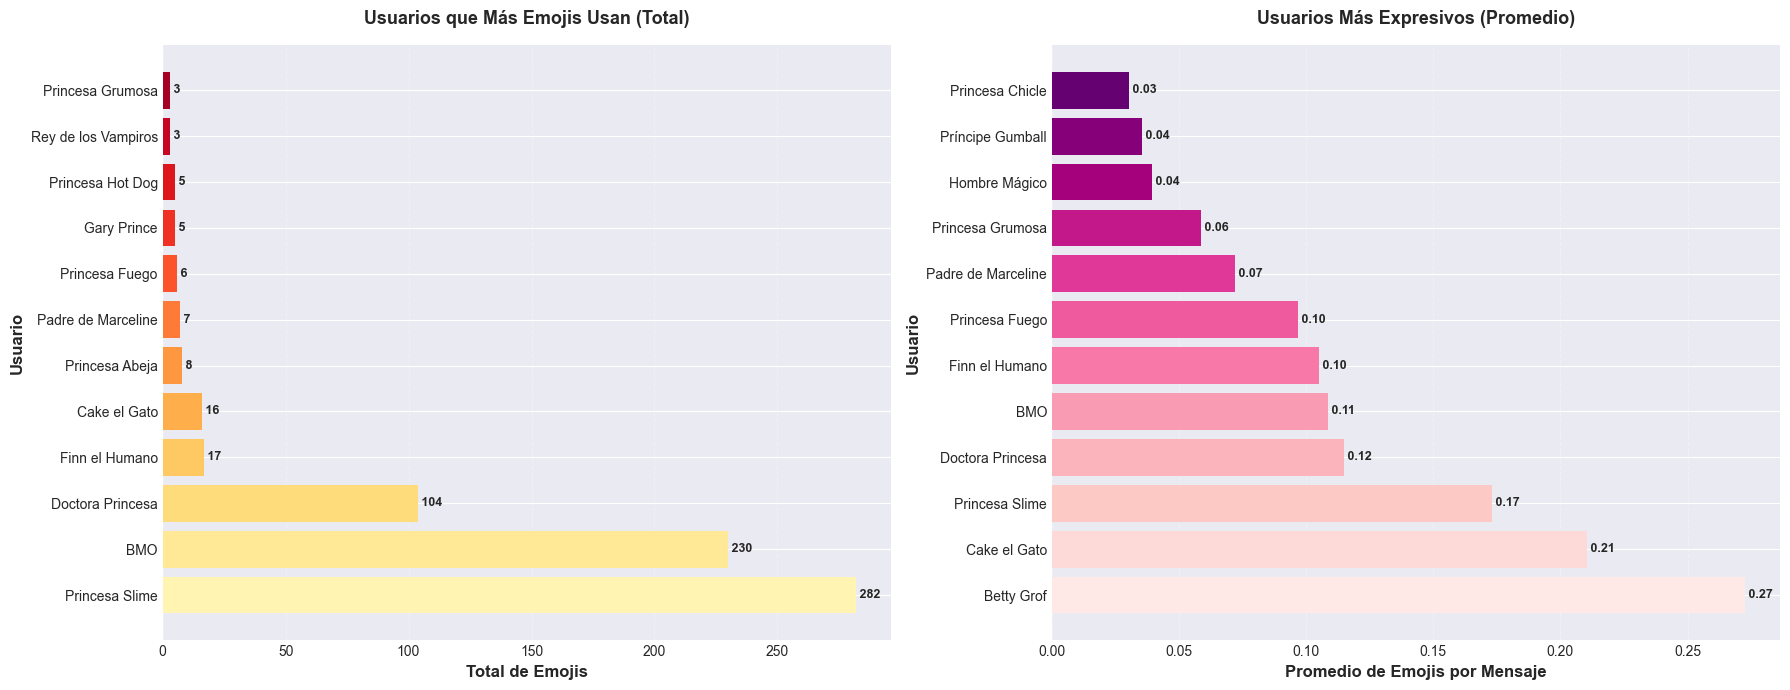


Estadísticas de uso de emojis:
   Total de emojis: 704
   Mensajes con emojis: 648 (6.0%)
   Promedio general: 0.07
   Promedio (solo mensajes con emojis): 1.09


In [42]:
# Emojis por usuario
emojis_por_usuario = df_analisis.groupby('usuario')['num_emojis'].sum().sort_values(ascending=False).head(12)

# Promedio de emojis
mensajes_por_usuario_count = df_analisis.groupby('usuario').size()
promedio_emojis = (df_analisis.groupby('usuario')['num_emojis'].sum() / mensajes_por_usuario_count).sort_values(ascending=False).head(12)

# Crear figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfica 1: Total
colores1 = sns.color_palette('YlOrRd', len(emojis_por_usuario))
bars1 = ax1.barh(range(len(emojis_por_usuario)), emojis_por_usuario.values, color=colores1)
ax1.set_yticks(range(len(emojis_por_usuario)))
ax1.set_yticklabels(emojis_por_usuario.index)
ax1.set_xlabel('Total de Emojis', fontsize=12, weight='bold')
ax1.set_ylabel('Usuario', fontsize=12, weight='bold')
ax1.set_title('Usuarios que Más Emojis Usan (Total)', fontsize=13, pad=15, weight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, valor) in enumerate(zip(bars1, emojis_por_usuario.values)):
    ax1.text(valor, i, f' {int(valor)}', va='center', fontsize=9, weight='bold')

# Gráfica 2: Promedio
colores2 = sns.color_palette('RdPu', len(promedio_emojis))
bars2 = ax2.barh(range(len(promedio_emojis)), promedio_emojis.values, color=colores2)
ax2.set_yticks(range(len(promedio_emojis)))
ax2.set_yticklabels(promedio_emojis.index)
ax2.set_xlabel('Promedio de Emojis por Mensaje', fontsize=12, weight='bold')
ax2.set_ylabel('Usuario', fontsize=12, weight='bold')
ax2.set_title('Usuarios Más Expresivos (Promedio)', fontsize=13, pad=15, weight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, valor) in enumerate(zip(bars2, promedio_emojis.values)):
    ax2.text(valor, i, f' {valor:.2f}', va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

# Estadísticas
total_emojis = df_analisis['num_emojis'].sum()
mensajes_con_emojis = df_analisis[df_analisis['num_emojis'] > 0]

print(f"\nEstadísticas de uso de emojis:")
print(f"   Total de emojis: {total_emojis:,}")
print(f"   Mensajes con emojis: {len(mensajes_con_emojis):,} ({len(mensajes_con_emojis)/len(df_analisis)*100:.1f}%)")
print(f"   Promedio general: {total_emojis/len(df_analisis):.2f}")
if len(mensajes_con_emojis) > 0:
    print(f"   Promedio (solo mensajes con emojis): {total_emojis/len(mensajes_con_emojis):.2f}")

## Resumen Final

Este análisis ha explorado completamente el grupo de WhatsApp utilizando **expresiones regulares** extensivamente.

### Técnicas Aplicadas:
- Parseo de mensajes con regex
- Anonimización completa de usuarios y contenido
- Clasificación de tipos de mensajes
- Extracción de características (palabras, emojis, menciones)
- Limpieza y normalización de texto

### Protección de Privacidad:
- Todos los nombres reales han sido reemplazados por personajes ficticios
- Los nombres también fueron reemplazados dentro del contenido de los mensajes
- No se muestran datos sensibles en ningún resultado
- El archivo original no debe ser compartido, solo este notebook con los resultados

In [43]:
print("\n" + "="*70)
print("ANÁLISIS COMPLETADO")
print("="*70)
print(f"\nDatos procesados:")
print(f"   - {total_mensajes:,} mensajes analizados")
print(f"   - {total_usuarios} usuarios anonimizados")
print(f"   - {dias_activos} días de actividad")
print(f"   - {total_palabras:,} palabras procesadas")
print(f"\nGráficas generadas: 9")
print(f"Análisis realizados: 10")
print(f"\nPrivacidad: Todos los datos personales han sido anonimizados")
print(f"Técnica principal: Expresiones Regulares (regex)")
print("\n" + "="*70)


ANÁLISIS COMPLETADO

Datos procesados:
   - 10,785 mensajes analizados
   - 26 usuarios anonimizados
   - 589 días de actividad
   - 39,819 palabras procesadas

Gráficas generadas: 9
Análisis realizados: 10

Privacidad: Todos los datos personales han sido anonimizados
Técnica principal: Expresiones Regulares (regex)

